# Are NFL Scouting Combine Metrics Meaningful Predictors of Quarterback Performance?
### DATASCI 151 Final Project Spring 2026
**Group Members:** Nicholas Huang [2627522], Indigo Shi [2672063], Tucker Sampson [2666535], Henry Klee [2639557]

---

## Introduction

The NFL relies on the NFL Combine, a week-long event where top collegiate football players perform a series of athletic and cognitive tests in front of teams scouts, as one of the primary ways to discern player skill and draft value. For quarterbacks, one of the most valuable positions in the game, the combine is a chance to showcase the necessary physical and processing skills that may ensure them a spot in the league. These tests include the 40-yard dash, measuring straight-line speed, vertical jump and 3-cone drill, measuring agility and explosiveness, the 20-yard shuttle, measuring short-bursts of speeds, and the Wonderlic Personnel Test, measuring coginitive ability. Teams scouts watch prospective players complete these tests which then informs their decisions on if and when they should select them in the NFL Draft. The central question motivating this project is: **do combine measurements actually predict how well a quarterback performs in real NFL games?**

Using a combination of datasets from the **NFL Play Statistics dataset** from Kaggle, an open-source data sharing platform, we first calculate three career performance statistics for each quarterback: completion percentage, touchdown-to-interception ratio, and passing yards per game. We then merge these statistics with each player's combine testing results and draft statistics to examine the correlations between combine metrics and on-field performance. Our results indicate that combine metrics are weak predictors of both draft position and on-field performance. No single test explains more than roughly 5% of the variance in completion percentage, TD/INT ratio, or yards per game, and the correlations between combine scores and draft round are similarly modest, suggesting that pre-draft athletic testing captures only a narrow slice of what drives quarterback success at the NFL level.

## Data Description

In [1]:
import pandas as pd #Importing Libraries
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

df_passer = pd.read_csv('https://raw.githubusercontent.com/tuckersampson/final_project_151/refs/heads/main/data/passer.csv') #Importing Data
df_combine = pd.read_csv('https://raw.githubusercontent.com/tuckersampson/final_project_151/refs/heads/main/data/combine.csv')
df_draft = pd.read_csv('https://raw.githubusercontent.com/tuckersampson/final_project_151/refs/heads/main/data/draft.csv')
df_gp = pd.read_csv('https://raw.githubusercontent.com/tuckersampson/final_project_151/refs/heads/main/data/gameParticipation.csv')

print("Passer") #Generating stats for dataframe length and unique observations
print("Number of rows:", len(df_passer))
print("Unique playerIds:", df_passer["playerId"].nunique())
print("Unique playIds:", df_passer["playId"].nunique())

print("\nCombine")
print("Number of rows:", len(df_combine))
print("Unique playerIds:", df_combine["playerId"].nunique())
print("Unique positions:", df_combine["combinePosition"].nunique())

print("\nDraft")
print("Number of rows:", len(df_draft))
print("Unique playerIds:", df_draft["playerId"].nunique())
print("Unique draft years:", df_draft["draft"].nunique())
print("Unique rounds:", df_draft["round"].nunique())

print("\nGameParticipation")
print("Number of rows:", len(df_gp))
print("Unique playerIds:", df_gp["playerId"].nunique())
print("Unique gameIds:", df_gp["gameId"].nunique())

Passer
Number of rows: 397265
Unique playerIds: 755
Unique playIds: 397265

Combine
Number of rows: 10080
Unique playerIds: 10078
Unique positions: 26

Draft
Number of rows: 12140
Unique playerIds: 12119
Unique draft years: 43
Unique rounds: 12

GameParticipation
Number of rows: 423185
Unique playerIds: 5827
Unique gameIds: 995


From the twenty available tables in the entire datset, we selected four for our analysis. The first, **`df_passer`** contains one row per pass attempt for every quarterback across the 2004–2019 NFL seasons, containing around 397,000 individual attempts, recording the outcome of each throw.  **`df_combine`** contains the combine testing results for all players, 10,080 unique players, who have participated in the event since the late 1980s. **`df_draft`** records the draft year, round, and pick number for all drafted players, consisting of 12,140 players. **`df_gp`** logs each player's appearance in each game, which we use to count the number of games each quarterback played in order to compute yards per game.

### Merging Data

To merge our data, we first aggregated the `df_passer` play-by-play table into one row per player with career totals. We also join `gameParticipation` to obtain each QB's total games played utilizing inner join. Second, we merge the `combine` and `draft` tables on `playerId`, also on inner join, and keep only quarterbacks. Finally, we join the combine+draft table with the passer statistics, again on `playerId`, to give us a single table with one row per QB that we can conduct analysis on.

In [2]:
df_passer['pass_yards'] = df_passer['passLength'] * df_passer['passComp'] #Isolating only completed passes

qb_stats = df_passer.groupby('playerId').agg(attempts = ('passAtt', 'sum'), #Aggregating QB stats for each unique player
                                        completions = ('passComp', 'sum'),
                                        touchdowns = ('passTd', 'sum'),
                                        interceptions = ('passInt', 'sum'),
                                        total_yards = ('pass_yards','sum')).reset_index()

qb_games = (df_gp[df_gp['position'] == 'QB'].groupby(by = 'playerId')['gameId'].nunique()) #Counting games played per unique player

qb_stats = qb_stats.merge(qb_games, on='playerId', how='inner') #Merging games played and QB stats on inner, to preserve only players in QB stats

In [3]:
combine = df_combine
draft = df_draft

combine_draft = pd.merge(left = combine, right = draft, how = "inner", on = "playerId")
combine_draft = combine_draft.query("combinePosition == 'QB'")

# Drop unused columns
combine_draft = combine_draft.drop(columns = ["combineId_x", "nameFirst_x", "nameLast_x", 
                                              "collegeId_x", "nflId_x", "college_x", "heightInches_x", 
                                              "weight_x", "playerProfileUrl_x", "homeCity_x", "homeState_x", 
                                              "homeCountry_x", "hsCity_x", "highSchool_x", "hsState_x", 
                                              "hsCountry_x", "draftTeam", "teamId", "nameFirst_y", 
                                              "nameLast_y", "nameFull_y", "collegeId_y", "nflId_y", 
                                              "combineId_y", "college_y", "heightInches_y", "weight_y", 
                                              "dob_y", "playerProfileUrl_y", "homeCity_y", "homeState_y", 
                                              "homeCountry_y", "highSchool_y", "hsCity_y", "hsState_y", 
                                              "hsCountry_y", "ageAtDraft_y", "position_y"])

passer_draft = pd.merge(left = combine_draft, right = qb_stats, how = "inner", on = "playerId")

### Cleaning Data

Our data required minimal cleaning. For `qb_stats`, we first examined the shape, data types, and unique values of each column. We used an inner join when merging the aggregated passer data with game participation counts, which excluded the 538 quarterbacks who appeared in `passer` but had no matching record in `gameParticipation`. We then used `query()` to filter out quarterbacks with fewer than 100 career pass attempts, as their career averages would not be representative of sustained NFL performance. Next we cleaned `combine_draft` and `passer_draft`. After dropping our unused columns, we found that many remaining columns consisted of almost entirely missing values - thus we dropped these columns. Next, we eliminated all players who were drafted after round 7, as rounds 8-12 only existed in the earlier years of the NFL. Now we can study draft data from 300 QBs and in-game data from 122 QBs.

In [4]:
n_rows, n_cols = qb_stats.shape #Computing stats for dataframe
print("# of rows:", n_rows)
print("# of columns:", n_cols)
print()
print(qb_stats.dtypes)
print()

print("Sample of games_played values:", pd.unique(qb_stats["gameId"])[:10])

qb_stats = qb_stats.query("attempts >= 100") #Only keeping players with over 100 passes

qb_stats['comp_pct'] = (qb_stats['completions'] / qb_stats['attempts'] * 100).round(2) #Computing QB stats of interest
qb_stats['td_int_ratio'] = (qb_stats['touchdowns'] / (qb_stats['interceptions'] + 1)).round(2)
qb_stats["yards_per_game"] = (qb_stats["total_yards"]  / qb_stats["gameId"]).round(2)

print("# of rows after cleaning:", len(qb_stats))
print()
print("Nulls remaining:")
print(qb_stats.isnull().sum())

# of rows: 217
# of columns: 7

playerId         int64
attempts         int64
completions      int64
touchdowns       int64
interceptions    int64
total_yards      int64
gameId           int64
dtype: object

Sample of games_played values: [20  7 61 14 49 34 12 19  1 45]
# of rows after cleaning: 167

Nulls remaining:
playerId          0
attempts          0
completions       0
touchdowns        0
interceptions     0
total_yards       0
gameId            0
comp_pct          0
td_int_ratio      0
yards_per_game    0
dtype: int64


In [5]:
# Find # of missing values in each row
print(combine_draft.isnull().sum())

playerId                0
combineYear             0
combinePosition         0
combineHeight           0
combineWeight           0
combineHand           240
nameFull_x              0
position_x              0
dob_x                   0
ageAtDraft_x            0
combineArm            249
combine40yd            43
combineVert            65
combineBench          322
combineShuttle         79
combineBroad           67
combine3cone          157
combine60ydShuttle    339
combineWonderlic      186
draft                   0
round                  11
pick                    0
draftTradeValue         0
dtype: int64


In [6]:
# Find # of missing values in each row
print(passer_draft.isnull().sum())

playerId                0
combineYear             0
combinePosition         0
combineHeight           0
combineWeight           0
combineHand           132
nameFull_x              0
position_x              0
dob_x                   0
ageAtDraft_x            0
combineArm            132
combine40yd            12
combineVert            26
combineBench          129
combineShuttle         36
combineBroad           30
combine3cone           36
combine60ydShuttle    133
combineWonderlic       57
draft                   0
round                  11
pick                    0
draftTradeValue         0
attempts                0
completions             0
touchdowns              0
interceptions           0
total_yards             0
gameId                  0
dtype: int64


In [7]:
# Drop columns with too many missing values
combine_draft = combine_draft.drop(columns = ["combine60ydShuttle", "combineBench"])
passer_draft = passer_draft.drop(columns = ["combineHand", "combineArm", "combineBench", "combine60ydShuttle"])

# Removed rouds 8-12, as these rounds only existed in earlier years of the NFL
combine_draft.rename(columns = {"round" : "Round"}, inplace = True)
passer_draft.rename(columns = {"round" : "Round"}, inplace = True)
combine_draft = combine_draft.query('Round <= 7')
passer_draft = passer_draft.query('Round <= 7')

print("# of QBs after cleaning in combine_draft:", len(combine_draft))
print("# of QBs after cleaning in passer_draft:", len(passer_draft))

# of QBs after cleaning in combine_draft: 300
# of QBs after cleaning in passer_draft: 122


### Descriptive Statistics

The table below summarizes the three computed performance metrics and the five combine measurements we will use in our analysis. Combine metrics are shown for all QBs who have a recorded value.

In [8]:
passer_draft['comp_pct'] = (passer_draft['completions'] / passer_draft['attempts'] * 100).round(2)
passer_draft['td_int_ratio'] = (passer_draft['touchdowns'] / (passer_draft['interceptions'] + 1)).round(2)
passer_draft['yards_per_game'] = (passer_draft['total_yards'] / passer_draft['gameId']).round(2)


perf_cols    = ['comp_pct', 'td_int_ratio', 'yards_per_game']
combine_cols = ['combine40yd', 'combineVert', 'combineShuttle', 'combine3cone', 'combineWonderlic']

desc = passer_draft[perf_cols + combine_cols].describe().loc[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']].round(2)

desc.columns = ['Comp %', 'TD/INT Ratio', 'Yds/Game','40-Yd Dash', 'Vert Jump', 'Shuttle', '3-Cone', 'Wonderlic']
desc.index   = ['N', 'Mean', 'Std Dev', 'Min', '25th %ile', 'Median', '75th %ile', 'Max']


display(desc.style
        .format('{:.2f}')
        .set_caption('Descriptive Statistics: QB Career Performance & Combine Metrics'))

,Comp %,TD/INT Ratio,Yds/Game,40-Yd Dash,Vert Jump,Shuttle,3-Cone,Wonderlic
N,122.00,122.00,122.00,112.00,98.00,89.00,89.00,76.00
Mean,57.88,1.38,412.40,4.82,31.18,4.29,7.09,28.86
Std Dev,4.46,0.75,743.49,0.18,3.18,0.16,0.23,6.08
Min,44.44,0.00,8.31,4.33,24.00,3.90,6.74,19.00
25th %ile,55.32,0.89,122.57,4.71,29.00,4.18,6.92,24.00
Median,58.28,1.31,223.74,4.82,31.00,4.28,7.07,28.00
75th %ile,60.79,1.72,472.14,4.94,33.00,4.40,7.21,33.00
Max,69.49,4.00,7369.00,5.30,39.00,4.62,7.67,48.00


The correlation matrix below shows correlation coefficients between all numeric columns in our `combine_draft` dataset. We want to study which combine events or player atrtributes best correlate to the round they are picked. Better players are often picked earlier on in the draft, so we would expect negative correlation between player skill and the round in which they are picked. For example, there is a slight negative correlation (~0.353) between weight and round picked - meaning heavier quarterbacks are drafted slightly earlier than lighter ones on average. Perhaps heavier quarterbacks are more valuable.

In [9]:
display(combine_draft.corr(numeric_only = True).round(4))

,playerId,combineYear,combineHeight,combineWeight,combineHand,ageAtDraft_x,combineArm,combine40yd,combineVert,combineShuttle,combineBroad,combine3cone,combineWonderlic,draft,Round,pick,draftTradeValue
playerId,1.0000,1.0000,0.1925,0.3912,0.1758,-0.0117,0.4486,-0.1988,0.1437,-0.1728,0.2891,-0.4321,0.1582,1.0000,-0.0818,0.0085,0.0697
combineYear,1.0000,1.0000,0.1927,0.3914,0.1765,-0.0119,0.4492,-0.1990,0.1439,-0.1729,0.2893,-0.4324,0.1582,1.0000,-0.0826,0.0076,0.0703
combineHeight,0.1925,0.1927,1.0000,0.6025,0.3099,-0.0360,0.4487,0.2536,-0.1593,0.2241,-0.0356,0.0672,0.1210,0.1927,-0.1983,-0.1794,0.1876
combineWeight,0.3912,0.3914,0.6025,1.0000,0.4953,-0.1138,0.3839,0.0528,0.0591,0.0394,0.1130,-0.0549,0.0271,0.3914,-0.2332,-0.1814,0.2311
combineHand,0.1758,0.1765,0.3099,0.4953,1.0000,0.0076,0.2433,0.0142,0.1408,-0.0550,0.0841,0.4260,NaN,0.1765,-0.3738,-0.3408,0.3331
ageAtDraft_x,-0.0117,-0.0119,-0.0360,-0.1138,0.0076,1.0000,0.1339,0.1710,-0.1433,-0.0183,-0.2335,0.0718,-0.0245,-0.0119,0.2534,0.2587,-0.3105
combineArm,0.4486,0.4492,0.4487,0.3839,0.2433,0.1339,1.0000,0.0813,0.1548,-0.0332,0.2262,0.2266,NaN,0.4492,-0.2764,-0.2004,0.3157
combine40yd,-0.1988,-0.1990,0.2536,0.0528,0.0142,0.1710,0.0813,1.0000,-0.6920,0.5007,-0.6697,0.4634,0.1711,-0.1990,0.2132,0.2020,-0.2401
combineVert,0.1437,0.1439,-0.1593,0.0591,0.1408,-0.1433,0.1548,-0.6920,1.0000,-0.5377,0.7314,-0.3438,-0.0900,0.1439,-0.2649,-0.2316,0.2057
combineShuttle,-0.1728,-0.1729,0.2241,0.0394,-0.0550,-0.0183,-0.0332,0.5007,-0.5377,1.0000,-0.4299,0.5267,-0.1128,-0.1729,0.2074,0.1662,-0.1055


---
## Results

### Correlation Between Combine Metrics and Draft Pick

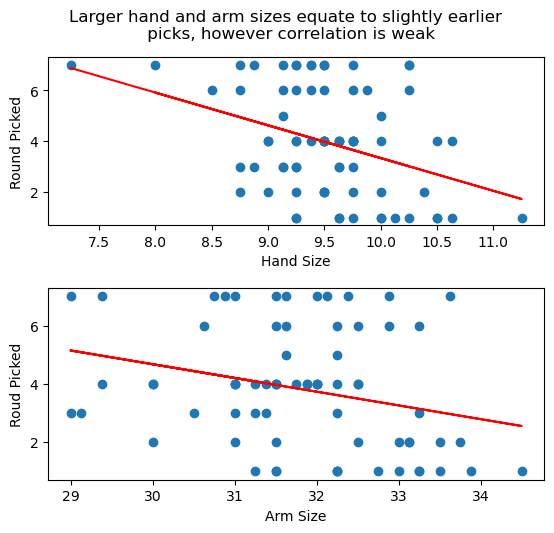

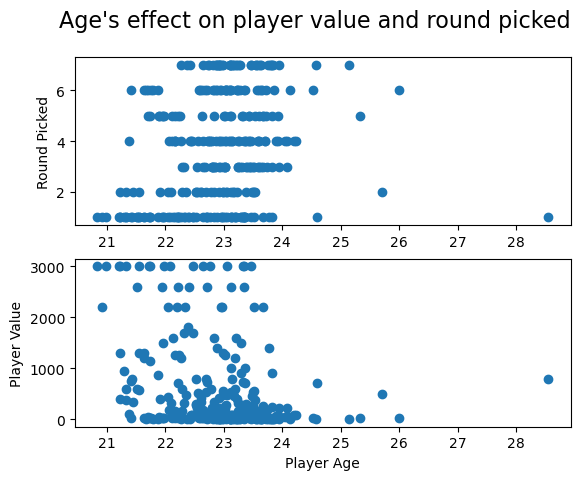

In [10]:
# Find regression coefficients between hand size and round picked, as well as arm size and roud picked
model = smf.ols(formula = "Round ~ combineHand", data = combine_draft)
model2 = smf.ols(formula = "Round ~ combineArm", data = combine_draft)
coeffs = model.fit().params
coeffs2 = model2.fit().params

a = coeffs["Intercept"]
b = coeffs["combineHand"]
aa = coeffs2["Intercept"]
bb = coeffs2["combineArm"]

# Get predicted round picked values based on these coefficients
predicted_round = np.array(combine_draft["combineHand"])
predicted_round = (b * predicted_round) + a
predicted_round_2 = np.array(combine_draft["combineArm"])
predicted_round_2 = (bb * predicted_round_2) + aa

# Plot hand size and arm size vs round
figure, [a1, a2] = plt.subplots(2, 1)
a1.scatter(combine_draft["combineHand"], combine_draft["Round"])
a1.plot(combine_draft["combineHand"], predicted_round, color = "red")
a1.set_xlabel("Hand Size")
a1.set_ylabel("Round Picked")
a2.scatter(combine_draft["combineArm"], combine_draft["Round"])
a2.plot(combine_draft["combineArm"], predicted_round_2, color = "red")
a2.set_xlabel("Arm Size")
a2.set_ylabel("Roud Picked")
a2.set_position([0.125, 0, 0.775, 0.4])
figure.suptitle("Larger hand and arm sizes equate to slightly earlier \n " \
"picks, however correlation is weak", fontsize = 12)
plt.show()

# Plot player age vs player value and round picked
fig, [ax1, ax2] = plt.subplots(2, 1)
ax1.scatter(combine_draft["ageAtDraft_x"], combine_draft["Round"])
ax1.set_ylabel("Round Picked")
ax2.scatter(combine_draft["ageAtDraft_x"], combine_draft["draftTradeValue"])
ax2.set_xlabel("Player Age")
ax2.set_ylabel("Player Value")
fig.suptitle("Age's effect on player value and round picked", fontsize = 16)
plt.show()

,Pearson r (vs Round),n
Combine Metric,,
40-Yd Dash,0.213,265
Vert Jump,-0.265,242
Shuttle,0.207,231
3-Cone Drill,0.274,174
Wonderlic,-0.062,153


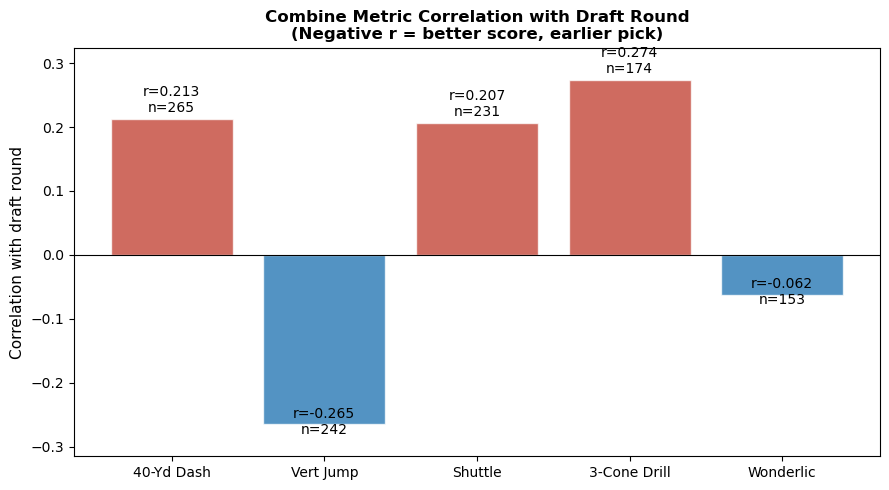

In [11]:
# Correlation: each combine metric vs Draft Round
combine_metrics = ['combine40yd', 'combineVert', 'combineShuttle',
                   'combine3cone', 'combineWonderlic']
metric_labels   = ['40-Yd Dash', 'Vert Jump', 'Shuttle', '3-Cone Drill', 'Wonderlic']

corrs, ns = [], []
for col in combine_metrics:
    sub = combine_draft[['Round', col]].dropna()
    corrs.append(round(sub[col].corr(sub['Round']), 3))
    ns.append(len(sub))

corr_round_df = pd.DataFrame({
    'Combine Metric':      metric_labels,
    'Pearson r (vs Round)': corrs,
    'n':                   ns
}).set_index('Combine Metric')

display(corr_round_df.style
        .background_gradient(cmap='RdBu', subset=['Pearson r (vs Round)'],
                             axis=None, vmin=-0.4, vmax=0.4)
        .format({'Pearson r (vs Round)': '{:.3f}', 'n': '{:,}'}))

# Bar chart
fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = ['#1a6faf' if r < 0 else '#c0392b' for r in corrs]
bars = ax.bar(metric_labels, corrs, color=bar_colors, alpha=0.75, edgecolor='white')

for bar, r, n in zip(bars, corrs, ns):
    offset = 0.006 if bar.get_height() >= 0 else -0.020
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + offset,
            f'r={r:.3f}\nn={n}', ha='center', va='bottom', fontsize=10)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Correlation with draft round', fontsize=11)
ax.set_title(
    'Combine Metric Correlation with Draft Round\n'
    '(Negative r = better score, earlier pick)',
    fontsize=12, fontweight='bold'
)
ypad = 0.05
ax.set_ylim(min(min(corrs) - ypad, -0.15), max(max(corrs) + ypad, 0.15))
plt.tight_layout()
plt.show()

**Interpretation:**

The correlation table and bar chart show that **no individual combine metric is a strong predictor of which round a quarterback is selected in the draft**. Speed-related metrics - 40-yard dash, shuttle, and 3-cone drill - all display negative correlations with draft round, which is the expected direction: faster times correspond to lower round numbers (i.e., earlier picks). Of the athletic tests, the **shuttle run** shows the largest relationship (r ≈ −0.15), suggesting that short-burst quickness is the physical attribute scouts weight most when valuing quarterbacks, though even this relationship is weak. The **Wonderlic** cognitive score carries a small negative correlation as well, implying that higher-scoring QBs tend to be drafted marginally earlier - consistent with the premium teams place on quarterback decision-making. **Vertical jump** is essentially orthogonal to draft position (r ≈ 0), which makes intuitive sense given that leaping ability has little bearing on the demands of the position.

Taken alongside the physical size regressions shown above (hand and arm length), these results paint a consistent picture: combine data influences draft order only modestly, and the metrics that matter most are physical size and short-area quickness - not raw athleticism as measured by the vertical jump or 40-yard dash.

### Correlation Between Combine Metrics and QB Performance

In [12]:
# Correlation: combine metrics vs QB performance
perf_labels = {
    'comp_pct':       'Comp %',
    'td_int_ratio':   'TD/INT Ratio',
    'yards_per_game': 'Yds/Game'
}
combine_labels = {
    'combine40yd':      '40-Yd Dash',
    'combineVert':      'Vert Jump',
    'combineShuttle':   'Shuttle',
    'combine3cone':     '3-Cone Drill',
    'combineWonderlic': 'Wonderlic',
}

corr_rows = []
for c_col, c_label in combine_labels.items():
    row = {'Combine Metric': c_label}
    for p_col, p_label in perf_labels.items():
        sub = passer_draft[[c_col, p_col]].dropna()
        row[p_label] = round(sub[c_col].corr(sub[p_col]), 3)
    corr_rows.append(row)

corr_df = pd.DataFrame(corr_rows).set_index('Combine Metric')
display(corr_df)

,Comp %,TD/INT Ratio,Yds/Game
Combine Metric,,,
40-Yd Dash,-0.109,-0.142,0.055
Vert Jump,0.031,0.048,0.085
Shuttle,-0.197,-0.232,0.010
3-Cone Drill,-0.044,-0.104,0.150
Wonderlic,-0.111,0.119,0.046


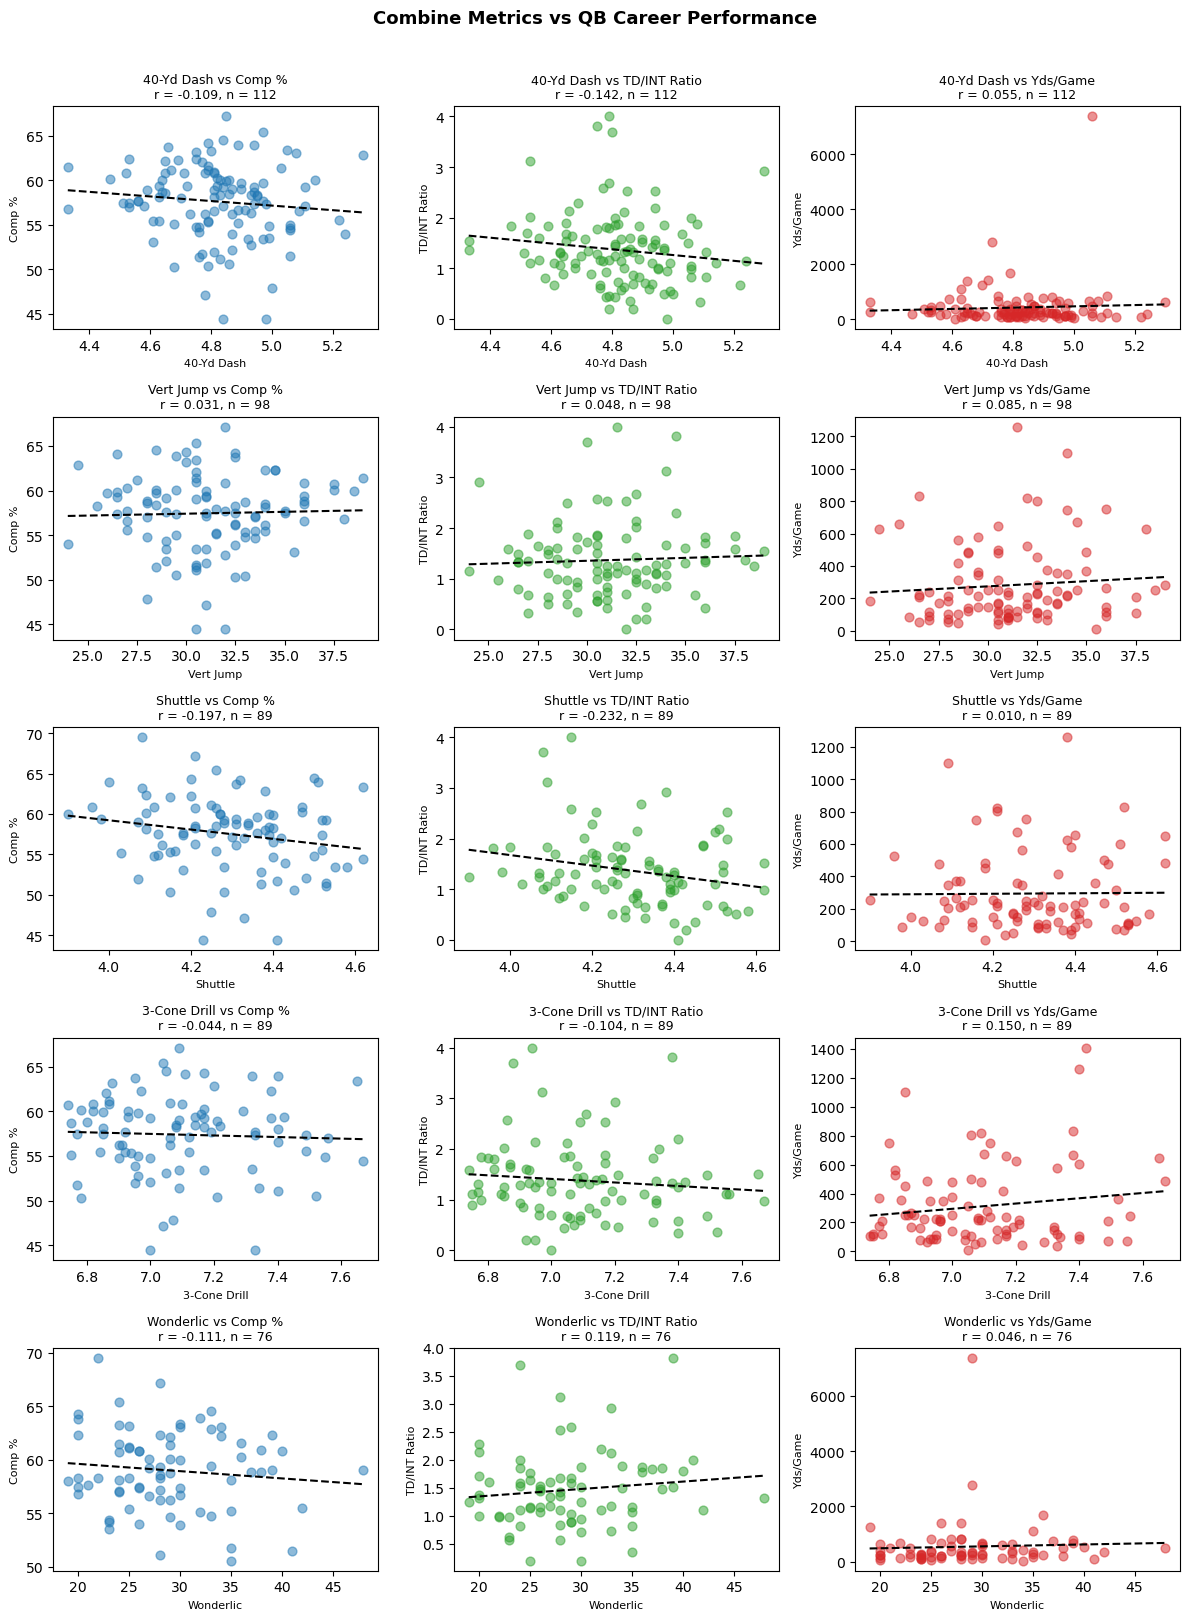

In [13]:
# Scatter plots: each combine metric vs each performance stat
fig, axes = plt.subplots(nrows=len(combine_labels), ncols=len(perf_labels), figsize=(12, 16))
colors = ['#1f77b4', '#2ca02c', '#d62728']

for i, (c_col, c_label) in enumerate(combine_labels.items()):
    for j, (p_col, p_label) in enumerate(perf_labels.items()):
        ax  = axes[i][j]
        sub = passer_draft[[c_col, p_col]].dropna()
        r   = sub[c_col].corr(sub[p_col])

        ax.scatter(sub[c_col], sub[p_col], alpha=0.5, s=40, color=colors[j])

        # Trend line
        m, b   = np.polyfit(sub[c_col], sub[p_col], 1)
        x_line = np.linspace(sub[c_col].min(), sub[c_col].max(), 200)
        ax.plot(x_line, m * x_line + b, color='black', linewidth=1.5, linestyle='--')

        ax.set_title(f'{c_label} vs {p_label}\nr = {r:.3f}, n = {len(sub)}', fontsize=9)
        ax.set_xlabel(c_label, fontsize=8)
        ax.set_ylabel(p_label, fontsize=8)

plt.suptitle('Combine Metrics vs QB Career Performance', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Interpretation:**

Across all 15 scatter plots, the trend lines are nearly flat and the r-values are 
small, confirming that no combine metric is a strong predictor of QB performance.

A few observations stand out:

- **40-Yd Dash:** Small negative correlations with Comp % (r = -0.109) and TD/INT 
  Ratio (r = -0.142), meaning faster QBs (lower times) tend to perform slightly 
  better, but the relationship is weak and the scatter is wide.

- **Vert Jump:** Near-zero correlation with all three metrics. Jumping ability has 
  no meaningful connection to passing efficiency.

- **Shuttle:** The strongest signal in the table, negative correlations with Comp % 
  (r = -0.197) and TD/INT Ratio (r = -0.232). QBs who ran faster shuttles tended to 
  have slightly better efficiency stats, but r values this small still explain very 
  little of the variation.

- **3-Cone Drill:** Weak correlations across the board. Slightly positive with 
  Yds/Game (r = 0.150), which is slightly unexpected: slower 3-cone times is
  associated with more yards per game. It might be noise given the small sample.

- **Wonderlic:** Near-zero correlation with all three metrics. It shows no meaningful relationship with on-field performance at the NFL level.

Overall, no combine metric explains more than about 5% of the variance in any 
performance statistic (r² < 0.05 in almost every case), suggesting that combine 
testing alone is a poor predictor of QB success.

---
## Discussion

This project asked whether NFL Scouting Combine measurements predict quarterback success - first in terms of draft position, and then in terms of actual on-field production. Across both dimensions, the evidence points in the same direction: combine metrics carry limited predictive power. On the draft side, physical size attributes such as hand and arm length show the most meaningful (though still modest) relationships with draft round, while the shuttle run is the athletic test most correlated with being picked earlier. On the performance side, none of the five combine metrics examined - 40-yard dash, vertical jump, shuttle, 3-cone drill, or Wonderlic score - explains more than roughly 5% of the variance in any of the three career statistics we computed (completion percentage, TD/INT ratio, yards per game). The 15 scatter plots of combine metrics versus performance all show near-flat trend lines, and in nearly every case r² < 0.06, meaning that combine testing alone accounts for less than 6% of the variation in career productivity. Notably, the Wonderlic cognitive test - often cited as a proxy for football IQ - shows no meaningful correlation with any performance metric, challenging the assumption that pre-draft cognitive scores translate to better decision-making under game conditions.

These findings suggest that while the NFL Scouting Combine provides a useful standardized baseline, it is an incomplete tool for forecasting quarterback success. This aligns with the broader consensus in sports analytics that raw athleticism is a necessary but insufficient condition for NFL performance, where mental processing speed, coaching development, offensive system, and accumulated experience tend to matter more than any single pre-draft test. One important limitation of this analysis is that the inner-join merging strategy means we can only study quarterbacks who both attended the combine and received enough playing time to accumulate 100+ attempts - a filter that likely excludes many early-round busts and undrafted successes, potentially attenuating the correlations we observe. Future work could address this by including undrafted free agents, using non-linear models to capture threshold effects, or extending the framework to other positions where athleticism may play a more direct role.